<a href="https://colab.research.google.com/github/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/IyC2026_RETO_DoubleML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Impacto del plan 401(k) en Riqueza Financiera


En la clase pasada, como aplicación del Método Double ML, consideramos la estimación del efecto de la elegibilidad  en planes 401(k) sobre los activos acumulados. Los planes 401(k) son cuentas de pensión patrocinadas por los empleadores. El problema clave al determinar el efecto de la participación en planes 401(k) sobre los activos acumulados es la **heterogeneidad de los ahorradores**, junto con el hecho de que la decisión de inscribirse en un 401(k) **no es aleatoria**.

El reto de esta semana consiste en determinar el **efecto causal de la participación en un plan 401k (p401) sobre la riqueza financiera (net_tfa)**

### Datos


In [ ]:
!pip install wget
!pip install formulaic

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=3eff0f433c4557a7270df69a3e358986e4db5b1fd8e0f4d288b352e07acf93b0
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.8 MB/s eta 0:00:00


In [ ]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.base import TransformerMixin, BaseEstimator, clone
from IPython.display import Markdown
import wget
import seaborn as sns
from formulaic import Formula
import warnings
warnings.simplefilter('ignore')
np.random.seed(1234)

In [ ]:
file = "https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/401k.csv"
data = pd.read_csv(file)

In [ ]:
data.head()

,ira,a401,hval,hmort,hequity,nifa,net_nifa,tfa,net_tfa,tfa_he,...,i3,i4,i5,i6,i7,a1,a2,a3,a4,a5
0,0,0,69000,60150,8850,100,-3300,100,-3300,5550,...,1,0,0,0,0,0,1,0,0,0
1,0,0,78000,20000,58000,61010,61010,61010,61010,119010,...,0,1,0,0,0,0,0,0,1,0
2,1800,0,200000,15900,184100,7549,7049,9349,8849,192949,...,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,0,2487,-6013,2487,-6013,-6013,...,0,0,1,0,0,1,0,0,0,0
4,0,0,300000,90000,210000,10625,-2375,10625,-2375,207625,...,0,1,0,0,0,0,0,1,0,0


In [ ]:
readme = "https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/401k.md"
filename = wget.download(readme)
Markdown(open(filename, 'r').read())

# Pension 401(k) data set

## Description
Data set on financial wealth and 401(k) plan participation. The source of this data set is the `hdm` package in `R`. It was created on 2/20/2023, by calling the `data(pension)` command in `R` after loading the `hdm` package and then writing the created dataframe to a csv file.

## Format
Dataframe with the following variables (amongst others):

**p401**

participation in 401(k)

**e401**

eligibility for 401(k)

**a401**

401(k) assets

**tw**

total wealth (in US $)

**tfa**

financial assets (in US $)

**net_tfa**

net financial assets (in US $)

**nifa**

non-401k financial assets (in US $)

**net_nifa**

net non-401k financial assets

**net_n401**

net non-401(k) assets (in US $)

**ira**

individual retirement account (IRA)

**inc**

income (in US $)

**age**

age

**fsize**

family size

**marr**

married

**pira**

participation in IRA

**db**

defined benefit pension

**hown**

home owner

**educ**

education (in years)

**male**

male

**twoearn**

two earners

**nohs, hs, smcol, col**

dummies for education: no high-school, high-school, some college, college

**hmort**

home mortage (in US $)

**hequity**

home equity (in US $)

**hval**

home value (in US $)

**i1-i7**

are income category indicators, 

**a1-a5**

are age category indicators

**icat** 

is the categorical variable that produces i1-i7. 

**ecat** 

is the categorical variable that generates education dummies (no high school, high school, some college, college). 

**Dum91**

is a dummy for 1991 which is equal to 1 for all observations because we are only use the 1991 SIPP. 

**tfa_he**

is net_tfa + home equity.

**zhat**

outcome of first stage prediction in instrumental variable analysis, from the academic paper that introduced this data


## Details
The sample is drawn from the 1991 Survey of Income and Program Participation (SIPP) and consists of 9,915 observations. The observational units are household reference persons aged 25-64 and spouse if present. Households are included in the sample if at least one person is employed and no one is self-employed. The data set was analysed in Chernozhukov and Hansen (2004) and Belloni et al. (2014) where further details can be found. They examine the effects of 401(k) plans on wealth using data from the Survey of Income and Program Participation using 401(k) eligibility as an instrument for 401(k) participation.

## References
V. Chernohukov, C. Hansen (2004). The impact of 401(k) participation on the wealth distribution: An instrumental quantile regression analysis. The Review of Economic and Statistics 86 (3), 735–751.

A. Belloni, V. Chernozhukov, I. Fernandez-Val, and C. Hansen (2014). Program evaluation with high-dimensional data. Working Paper.

## Preguntas 1 y 2

1. ¿Está la participación en el programa está asociada con riqueza financiera? Justifica tu respuesta

2. ¿Cuál es el "Average predictive effect" (APE) de *p401* en *net_tfa*?

Notemos que estos valores estimados están sesgados ya que no toman en cuenta la heterogeneidad de los ahorradores

In [ ]:
#Seleccionando variables
y = data['net_tfa'].values
D = data['e401'].values
D2 = data['p401'].values
D3 = data['a401'].values
X = data.drop(['e401', 'p401', 'a401', 'tw', 'tfa', 'net_tfa', 'tfa_he',
               'hval', 'hmort', 'hequity',
               'nifa', 'net_nifa', 'net_n401', 'ira',
               'dum91', 'icat', 'ecat', 'zhat',
               'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7',
               'a1', 'a2', 'a3', 'a4', 'a5'], axis=1)
X.columns

Index(['age', 'inc', 'fsize', 'educ', 'db', 'marr', 'male', 'twoearn', 'pira',
       'nohs', 'hs', 'smcol', 'col', 'hown'],
      dtype='object')

### Definimos una transformación para el feature engineering de los controles

In [ ]:
class FormulaTransformer(TransformerMixin, BaseEstimator):

    def __init__(self, formula, array=False):
        self.formula = formula
        self.array = array

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = Formula(self.formula).get_model_matrix(X)
        if self.array:
            return df.values
        return df

In [ ]:
transformer = FormulaTransformer("0 + poly(age, degree=6, raw=True) + poly(inc, degree=8, raw=True) "
                                 "+ poly(educ, degree=4, raw=True) + poly(fsize, degree=2, raw=True) "
                                 "+ male + marr + twoearn + db + pira + hown", array=True)

## Calculando el ATE de la participación en el plan 401k en los Activos Financieros Netos

Queremos estimadores válidos del efecto promedio del tratamiento (ATE) de  `p401` y  en `net_tfa`. Utilizamos modelos de ML para estimar las funciones $g_0$ y $m_0$ en el siguiente modelo

\begin{eqnarray}
 &  Y = D\theta_0 + g_0(X) + \zeta,  &  \quad E[\zeta \mid D,X]= 0,\\
 & D = m_0(X) +  V,   &  E[V \mid X] = 0.
\end{eqnarray}

## Preguntas 3, 4 y 5

3. Calcula el efecto promedio causal (ATE) de la participación en el plan 401k sobre la riqueza financiera.

4. ¿Cómo compara este efecto con el ATE de la elegibilidad a participar en este plan sobre la riqueza financiera (clase pasada)?

5. Justifica tu elección de los modelos de Machine Learning empleados para la estimación de *`y`* y de *`D`*

6. Elige una variable confusora y determina si ella genera la paradoja de Simpson.

7. Considera el Teorema de Firsch - Waugh - Lovell como lo vimos en las notas de clase y responde. ¿Es cierto que en los modelos lineales ya no puede ocurrir la paradoja de Simpson?

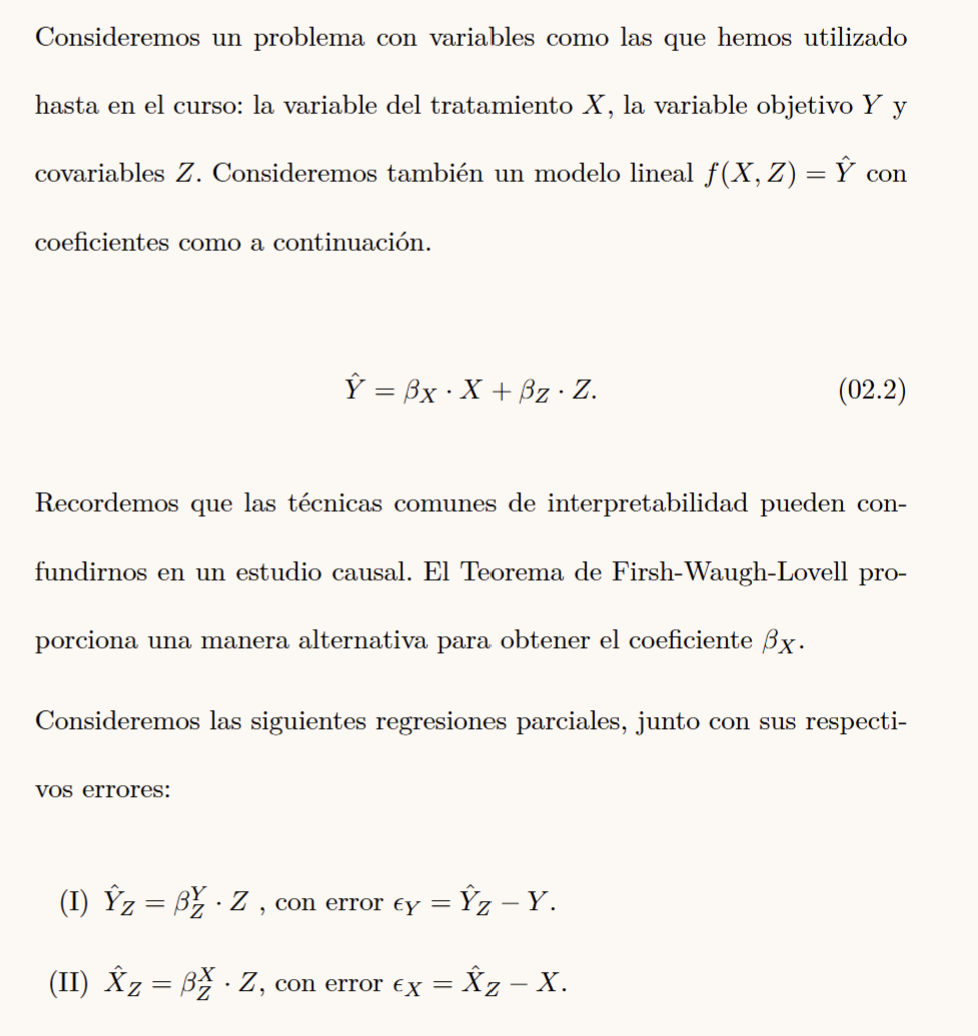   $\quad \quad $

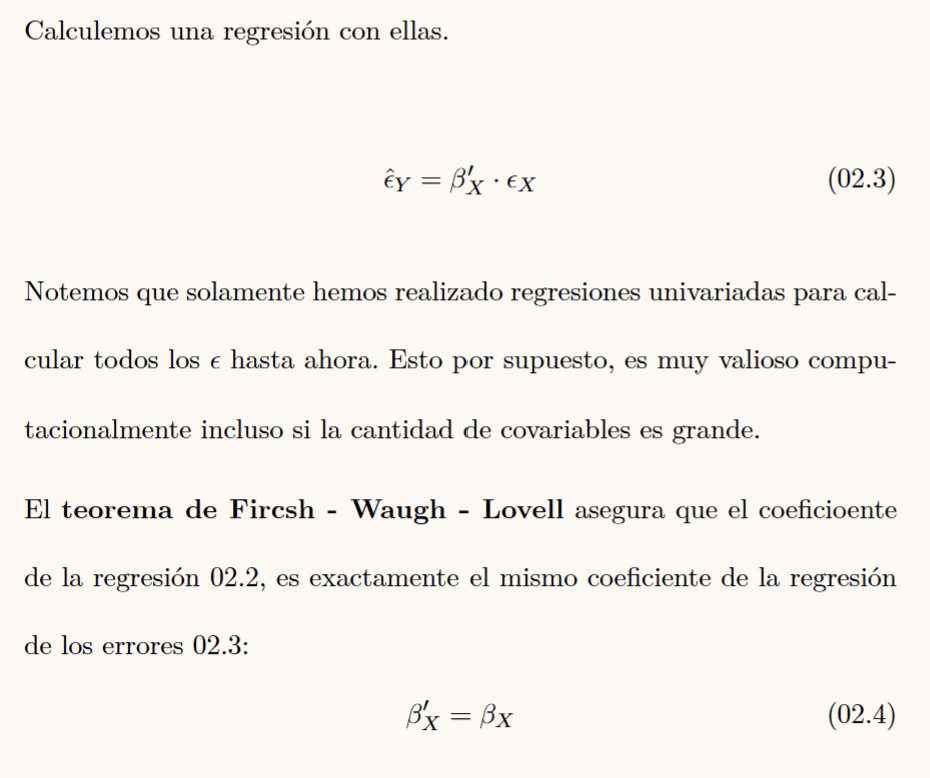